In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

Ford car model predict with car price 

In [2]:
df = pd.read_csv('ford.csv')

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [5]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [6]:
df.shape

(17966, 9)

Eda (Exploratory Data Analysis) and data cleaning

In [7]:
df.duplicated().sum()

np.int64(154)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(17812, 9)

In [10]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

Histogram ek graph hai jo dikhata hai ki data kis range me kitni baar aata hai.

<Axes: xlabel='price', ylabel='Count'>

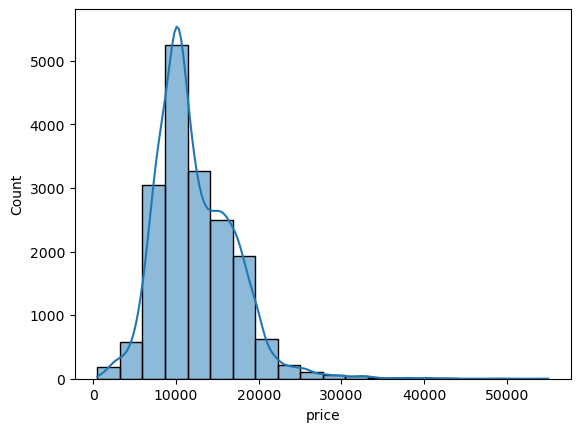

In [11]:
sns.histplot(data = df, x = 'price', bins=20, kde=True)

1. Most common price range<br>
-> Sabse unchi bar batati hai ki maximum cars kis price range me hain.
<br>
2. Skewness (Data kis side jhuk raha hai)<br>
-> Right Skewed (common in car prices) <br>
-> Most cars cheap hain, kuch bahut expensive cars bhi hain.
<br>
3. Outliers
-> Agar ek-do bars bahut door hain:<br>
-> Kuch unusually expensive cars hain (outliers).


Heatmap tab use karte hain jab hume multiple numerical features ke beech correlation ko ek hi graph me dekhna ho.

<Axes: >

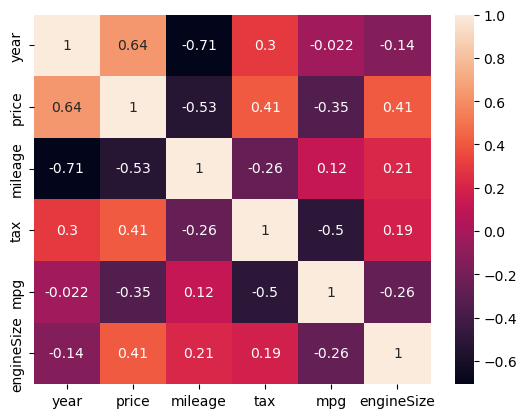

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

+1 → Strong positive correlation
 <br>
-1 → Strong negative correlation
<br>
0 → No correlation
<br>
Darker/lighter colors help quickly spot strong relationships

Bar Plot tab use karte hain jab hume categories ko compare karna ho.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

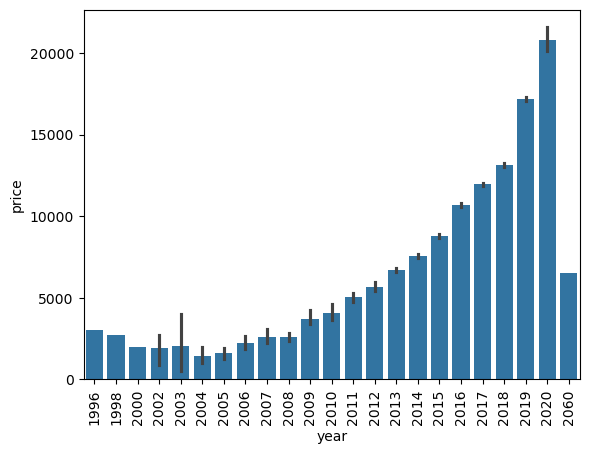

In [13]:
sns.barplot(data = df, x = 'year', y = 'price')
plt.xticks(rotation = 90)

1. Taller bar → Higher average price<br>
2. Shorter bar → Lower average price<br>
3. Compare prices across years easily<br>
4. Helps find trends in car prices over time<br>
5. Useful for understanding how the manufacturing year affects price.<br>

Scatter plot tab use karte hain jab do numerical variables ke beech relationship dekhna ho.

<Axes: xlabel='mileage', ylabel='price'>

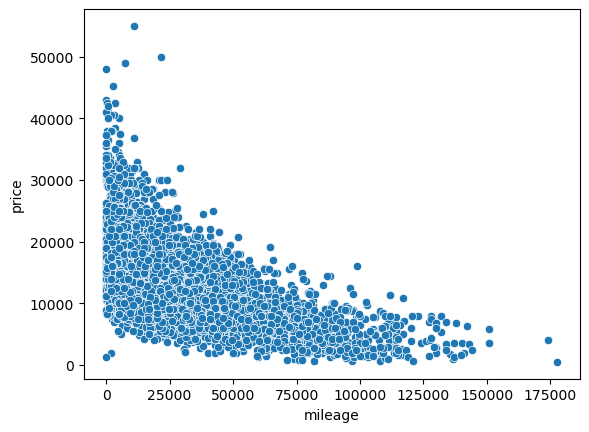

In [19]:
sns.scatterplot(data = df, x = 'mileage', y = 'price')

1. Each dot = one car<br>
2. Higher mileage → usually lower price<br>
3. Lower mileage → usually higher price<br>
4. Shows correlation between mileage and price<br>
5. Helps detect unusual cars (outliers)<br>

In [20]:
df.model.value_counts()

model
 Fiesta                   6509
 Focus                    4555
 Kuga                     2208
 EcoSport                 1127
 C-MAX                     542
 Ka+                       523
 Mondeo                    512
 B-MAX                     350
 S-MAX                     294
 Grand C-MAX               247
 Galaxy                    227
 Edge                      205
 KA                        197
 Puma                       79
 Tourneo Custom             69
 Grand Tourneo Connect      57
 Mustang                    57
 Tourneo Connect            32
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

Boxplot is used to understand the distribution of a numerical variable and detect outliers. It shows the median, spread of data (IQR),<br> and unusual values. When comparing groups, such as tax vs price, it helps compare price distributions across different tax categories.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, '0'),
  Text(1, 0, '20'),
  Text(2, 0, '22'),
  Text(3, 0, '30'),
  Text(4, 0, '110'),
  Text(5, 0, '115'),
  Text(6, 0, '120'),
  Text(7, 0, '125'),
  Text(8, 0, '135'),
  Text(9, 0, '140'),
  Text(10, 0, '145'),
  Text(11, 0, '150'),
  Text(12, 0, '155'),
  Text(13, 0, '160'),
  Text(14, 0, '165'),
  Text(15, 0, '185'),
  Text(16, 0, '190'),
  Text(17, 0, '195'),
  Text(18, 0, '200'),
  Text(19, 0, '205'),
  Text(20, 0, '210'),
  Text(21, 0, '220'),
  Text(22, 0, '230'),
  Text(23, 0, '235'),
  Text(24, 0, '240'),
  Text(25, 0, '260'),
  Text(26, 0, '265'),
  Text(27, 0, '270'),
  Text(28, 0, '290'),
  Text(29, 0, '300'),
  Text(30, 0, '305'),
  Text(31, 0, '325'),
  Text(32, 0, '330'),
  Text(33, 0, '555'),
  Text(34, 0, '570'),
  Text(35, 0, '580')])

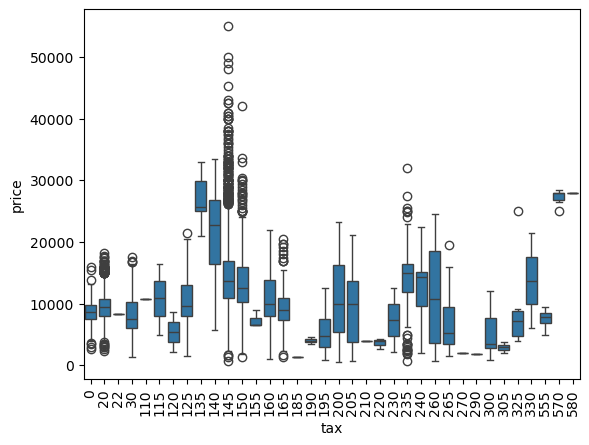

In [21]:
sns.boxplot(data = df, x = 'tax', y = 'price')
plt.xticks(rotation = 90)

In [22]:
df.engineSize.value_counts()

engineSize
1.0    7702
1.5    3393
2.0    3273
1.2    1613
1.6     918
1.1     550
1.4     112
2.3      80
0.0      51
5.0      45
1.8      35
2.2      13
2.5      13
1.3      12
3.2       1
1.7       1
Name: count, dtype: int64

<Axes: xlabel='engineSize', ylabel='price'>

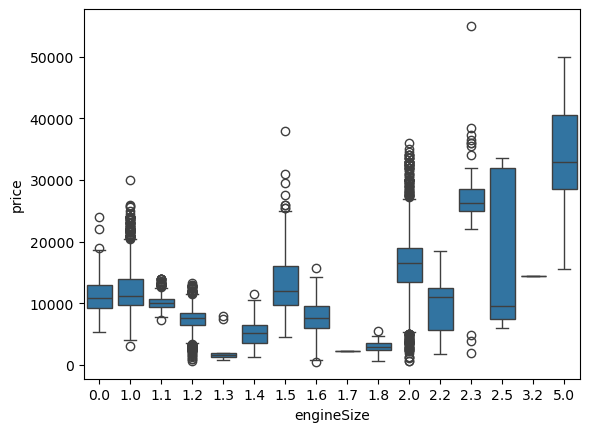

In [23]:
sns.boxplot(data = df,x = 'engineSize',y = 'price')

In [24]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

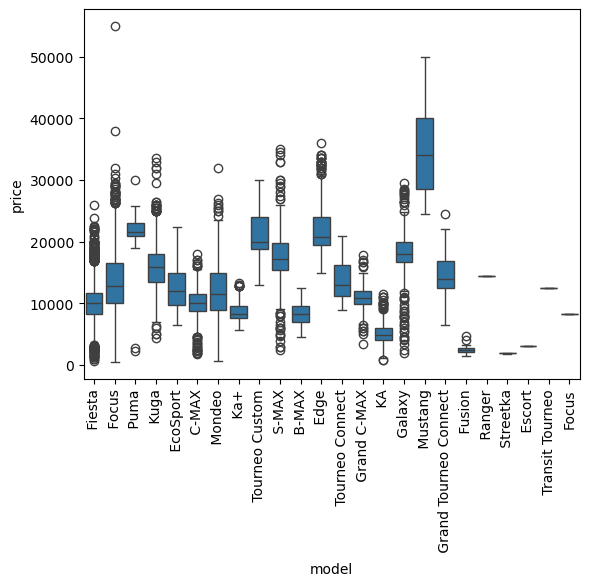

In [25]:
sns.boxplot(data = df, x = 'model',y = 'price')
plt.xticks(rotation = 90)

(extra blank spaces) ko remove karta hai.

In [26]:
df['model'] = df['model'].str.strip()

In [27]:
df[df['model'] == 'Mustang']

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
302,Mustang,2020,42489,Automatic,3500,Petrol,145,22.1,5.0
339,Mustang,2020,38489,Automatic,3500,Petrol,145,30.7,2.3
353,Mustang,2018,29998,Automatic,3000,Petrol,145,28.8,2.3
354,Mustang,2018,31498,Automatic,6250,Petrol,145,23.5,5.0
364,Mustang,2016,24999,Semi-Auto,42086,Petrol,570,23.5,5.0
387,Mustang,2019,39998,Automatic,5000,Petrol,145,22.6,5.0
741,Mustang,2018,29998,Manual,20847,Petrol,145,20.9,5.0
1793,Mustang,2018,29000,Automatic,11475,Petrol,145,28.8,2.3
1825,Mustang,2018,28750,Semi-Auto,6234,Petrol,145,28.8,2.3
2204,Mustang,2020,36500,Semi-Auto,672,Petrol,145,30.7,2.3


<Axes: xlabel='transmission', ylabel='price'>

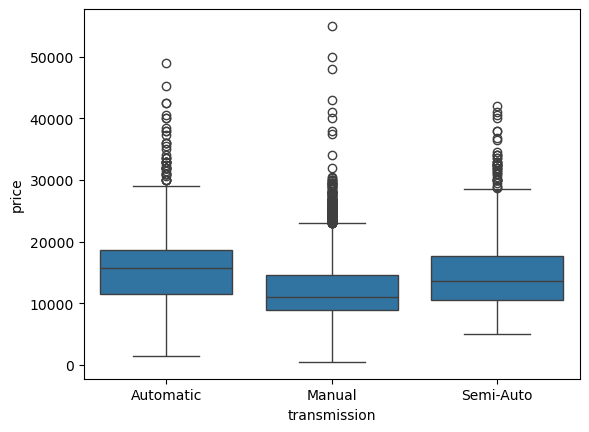

In [28]:
sns.boxplot( data = df, x = 'transmission', y = 'price')

<Axes: xlabel='fuelType', ylabel='price'>

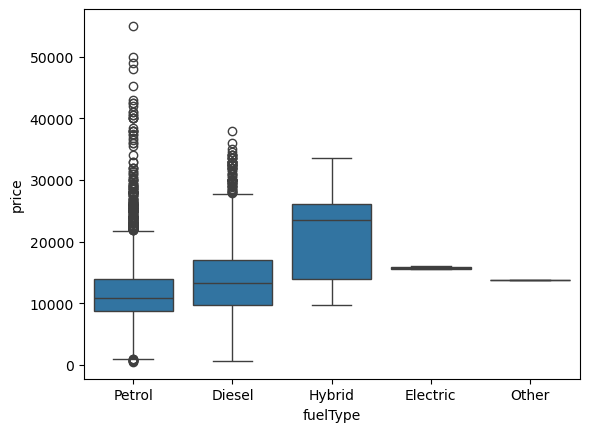

In [29]:
sns.boxplot( data = df, x = 'fuelType', y = 'price')

Independent variables (x) and dependent variable (y)

In [30]:
x = df.drop('price',axis=1)

In [31]:
x

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [32]:
y = df['price']

In [33]:
y

0        12000
1        14000
2        13000
3        17500
4        16500
         ...  
17961     8999
17962     7499
17963     9999
17964     8299
17965     8299
Name: price, Length: 17812, dtype: int64

one hot encoding to which is get best accuracy

In [34]:
one_hot_encode = pd.get_dummies(x, drop_first=True)

In [35]:
one_hot_encode

,year,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,40700,30,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,7010,20,67.3,1.6,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,5007,145,57.7,1.2,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [36]:
one_hot_encode = one_hot_encode.astype(int)

label encoding o which is get best accuracy

In [37]:
from sklearn.preprocessing import LabelEncoder

Xlabel = x.copy()
columns = ['model', 'transmission', 'fuelType']

for col in columns:
    le = LabelEncoder()
    Xlabel[col] = le.fit_transform(Xlabel[col])

In [38]:
Xlabel.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


Standardscaler

In [39]:
from sklearn.preprocessing import StandardScaler
cols = ['year','mileage','tax','mpg']
sd = StandardScaler()
one_hot_encode[cols] = sd.fit_transform(one_hot_encode[cols])


In [40]:
one_hot_encode

,year,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.554393,-0.736317,0.591380,-0.042291,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.067059,-0.562616,0.591380,-0.042291,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.041726,-0.665405,0.510777,-1.720193,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.041726,-1.127749,0.510777,-0.930592,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.067059,-0.344061,0.591380,-1.029292,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.394942,0.891875,-1.343079,-0.042291,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.907608,-0.843071,-1.504284,0.944711,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.554393,-0.946220,0.510777,-0.042291,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [41]:
from sklearn.preprocessing import StandardScaler

cols = ['model','year','mileage','tax','mpg']
sd = StandardScaler()
Xlabel[cols] = sd.fit_transform(Xlabel[cols])

In [42]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460252,0.067059,0,-0.382994,4,0.591380,-0.020597,1.0
1,-0.210686,0.554393,1,-0.736317,4,0.591380,-0.020597,1.0
2,-0.210686,0.067059,1,-0.562616,4,0.591380,-0.020597,1.0
3,-0.460252,1.041726,1,-0.665405,4,0.510777,-1.737858,1.5
4,-0.460252,1.041726,0,-1.127749,4,0.510777,-0.908836,1.0
...,...,...,...,...,...,...,...,...
17961,-1.708085,0.067059,1,-0.344061,4,0.591380,-1.066745,1.4
17962,-1.708085,-1.394942,1,0.891875,4,-1.343079,-0.020597,1.0
17963,-0.210686,-0.907608,1,-0.843071,0,-1.504284,0.926858,1.6
17964,1.037147,0.554393,1,-0.946220,4,0.510777,-0.020597,1.2


Machine Learning model train karne se pehle dataset ko do parts me divide karne ke liye use karte hain:<br>
Training Data (80%) → Model ko sikhane ke liye.<br>
Testing Data (20%) → Model ki performance check karne ke liye.

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(one_hot_encode, y, test_size=0.20, random_state=42)


Linear Regression model ko train karne ke liye use hota hai.

LinearRegression() is used to create a linear regression model, and fit(X_train, y_train) trains the model using the training data. During training, the model learns the relationship between input features and the target variable so it can make predictions on new data.

In [45]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


here test 20% data

In [46]:
y_predict = model.predict(X_test)
y_predict

array([22244.29737259, 15015.69077686, 16519.37159465, ...,
       10886.32301279, 20794.3954936 , 10788.03562901], shape=(3563,))

Left side (9891, 13006, 15284) = Original DataFrame ke index numbers <br>
Right side (22975, 18000, 18500) = Actual price values (target values)

In [47]:
y_test

9891     22975
13006    18000
15284    18500
6399      9985
8182      7998
         ...  
10527    15479
8915     11995
17393     9000
10483    18479
3460      9790
Name: price, Length: 3563, dtype: int64

compare b/w y_test and y_predict

R² Score is an evaluation metric used in regression problems. It measures how well the model explains the variance in the target variable. 

In [48]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_predict)
r2

0.8256616692448089

An R² value closer to 1 indicates a better-fitting model, while a value closer to 0 indicates poor predictive performance.


In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

r2_adjusted = 1 - ((1 - r2)*(n - 1)/(n - p - 1))
r2_adjusted


0.8240314156559958

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Xlabel, y, test_size=0.33, random_state=42)

In [100]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
y_predict = model.predict(X_test)
y_predict

array([16542.49279123, 15076.13328387, 16754.84502191, ...,
       13428.3035756 , 13136.9244477 , 13571.44806541], shape=(5878,))

In [104]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_predict)
r2

0.7167482414461022

In [108]:
n = X_test.shape[0]
p = X_test.shape[1]

r2_adjusted = 1 - ((1 - r2)*(n - 1)/(n - p - 1))
r2_adjusted

0.7163621426101112